In [1]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib
from matplotlib import animation

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')
from python.polygon_based_correction import *
from python.animation import *
from eval.eval import *
from python.dataset_conversion import *
from python.misprediction_classifier import *
from autoencoder.src.data_loader import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


# Polar interpolation

In [32]:
def eval_interpolation(interpolator, pts, verbose=False):
    """
    Evaluate the interpolation performance of a given interpolator.
    
    Args:
        interpolator: The interpolator to evaluate.
        pts: The points to interpolate.
        gt_pts: The ground truth points.
        
    Returns:
        The interpolation error.
    """
    pts = pts[:, :, :2]
    frame_cnt, pt_cnt = pts.shape[:2]
    interpolation_err = np.zeros((frame_cnt, pt_cnt))
    
    for frame_idx in range(frame_cnt):
        if verbose: 
            print(f'frame_idx: {frame_idx}')
        curr_frame_pts = pts[frame_idx]
        polygon_order = poly_4(curr_frame_pts)
        curr_frame_pts = curr_frame_pts[polygon_order]
        center_pos = curr_frame_pts.mean(axis=0)
        
        for pt_idx in range(pt_cnt):
            
            curr_pt = curr_frame_pts[pt_idx]
            curr_frame_curr_pt = curr_frame_pts.copy()
            curr_frame_curr_pt[pt_idx] = (0, 0)
            curr_pt_interpolated = interpolator(curr_frame_curr_pt, center_pos=center_pos, verbose=False)[pt_idx]
            assert curr_pt.shape == curr_pt_interpolated.shape, f'shape mismatch: {curr_pt.shape} != {curr_pt_interpolated.shape}'
            interpolation_err[frame_idx, pt_idx] = np.linalg.norm(curr_pt - curr_pt_interpolated)
            if verbose:
                print(f'curr_pt: {np.round(curr_pt, 2)}, curr_pt_interpolated: {np.round(curr_pt_interpolated, 2)}, err: {np.round(interpolation_err[frame_idx, pt_idx], 2)}')
            
    return interpolation_err

In [3]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores_corrected.slp'
corrected_dataset = sleap.load_file(corrected_dataset_path)
print(corrected_dataset)
gt_pts = get_all_untracked_points(corrected_dataset, interpolate=False, use_labeled_only=True)

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 2)


3000it [00:03, 942.40it/s]

Missing point count: 0
reorder_idx.shape: (17,)


In [4]:
def cart2pol(xy_arr, center_pos=(0, 0)):
    xy_arr = xy_arr - center_pos
    x = xy_arr[:, 0]
    y = xy_arr[:, 1]
    rho = np.hypot(x, y)  
    phi = np.arctan2(y, x)
    return np.array([rho, phi]).T

def pol2cart(rho_phi_arr, center_pos=(0, 0)):
    rho = rho_phi_arr[:, 0]
    phi = rho_phi_arr[:, 1]
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return np.array([x, y]).T + center_pos

def polar_interpolate(curr_frame_pts, non_missing_mask=None, center_pos=None, verbose=True):
    
    if non_missing_mask is None:
        non_missing_mask = ~(curr_frame_pts == 0).all(axis=1)
    
    first_non_missing_idx = np.where(non_missing_mask)[0][0]
    curr_frame_pts = np.roll(curr_frame_pts, -first_non_missing_idx, axis=0)
    non_missing_mask = np.roll(non_missing_mask, -first_non_missing_idx, axis=0)
    non_missing_indices = np.where(non_missing_mask)[0]
    
    if center_pos is None:
        center_pos = curr_frame_pts[non_missing_mask].mean(axis=0)
    
    polar_coords = cart2pol(curr_frame_pts, center_pos)
    polar_coords_deg = polar_coords.copy()
    polar_coords_deg[:, 1] = np.rad2deg(polar_coords_deg[:, 1])
    cart_interpolated_pts = np.zeros_like(curr_frame_pts)
    pt_cnt = len(curr_frame_pts)
    
    for pt_idx in range(pt_cnt):
        if non_missing_mask[pt_idx]:
            cart_interpolated_pts[pt_idx] = curr_frame_pts[pt_idx]
            continue
            
        prev_idx = non_missing_indices[non_missing_indices < pt_idx][-1] if any(non_missing_indices < pt_idx) else non_missing_indices[-1]
        next_idx = non_missing_indices[non_missing_indices > pt_idx][0] if any(non_missing_indices > pt_idx) else non_missing_indices[0]
        
        if next_idx > prev_idx:
            denom = next_idx - prev_idx
        else:
            denom = pt_cnt - (prev_idx - next_idx)
        weight = ((pt_idx - prev_idx) % pt_cnt) / denom
        r1, theta1 = polar_coords[prev_idx]
        r2, theta2 = polar_coords[next_idx]
        if verbose:
            print(f'prev_idx: {prev_idx}, next_idx: {next_idx}')
            print(f'r1: {r1}, theta1: {np.rad2deg(theta1)}')
            print(f'r2: {r2}, theta2: {np.rad2deg(theta2)}')
            print(f'weight: {weight}')

        r_interp = r1 + weight * (r2 - r1)
        
        # if theta1 > theta2:
        #     theta1, theta2 = theta2, theta1
        # if theta1 * theta2 < 0:
        #     if theta1 < 0:
        #         theta1 += 2*np.pi
        #     else:
        #         theta2 += 2*np.pi
        #     theta_offset = 2*np.pi
        # else:
        #     theta_offset = 0
        
        # if theta1 < 0:
        #     theta1 += 2*np.pi
        # if theta2 < 0:
        #     theta2 += 2*np.pi
        # if theta1 * theta2 < 0 and (theta1 < -np.pi/2 or theta2 < -np.pi/2):
        #     theta1 = theta1 + 2*np.pi if theta1 < 0 else theta1
        #     theta2 = theta2 + 2*np.pi if theta2 < 0 else theta2
        theta_diff = (theta2 - theta1)
        if theta_diff < 0:
            theta_diff += 2*np.pi
        theta_interp = theta1 + weight * theta_diff
        # if theta_interp > np.pi:
        #     theta_interp -= 2*np.pi
        
        if verbose:
            print(f'theta1: {np.rad2deg(theta1)}, theta2: {np.rad2deg(theta2)}')
        # theta_diff = (theta2 - theta1) + theta_offset
        
        # if theta1 > theta2:
        # #     theta2 += 2*np.pi
        # if verbose:
        #     print(f'interp theta before mod: {np.rad2deg(theta1 + weight * theta_diff)}')
        # theta_interp = np.mod(theta1 + weight * theta_diff, 2*np.pi)
        # theta_interp = theta1 + weight * theta_diff - theta_offset
        # theta_interp = theta1 + weight * theta_diff
        
        
        cart_interpolated_pts[pt_idx] = pol2cart(np.array([[r_interp, theta_interp]]), center_pos)[0]
        
        if verbose:
            n1, n2 = pol2cart(np.array([[r1, theta1], [r2, theta2]]), center_pos)
            print(f'r_interp: {r_interp}, theta_interp: {np.rad2deg(theta_interp)}')
            print(f'n1: {n1}, n2: {n2}')
            print(f'cart_interpolated_pts: {cart_interpolated_pts[pt_idx]}')

    cart_interpolated_pts = np.roll(cart_interpolated_pts, first_non_missing_idx, axis=0)
    return cart_interpolated_pts


In [31]:
frame0_pts = gt_pts[2]
frame0_polygon_order = poly_4(frame0_pts)
frame0_pts = frame0_pts[frame0_polygon_order]

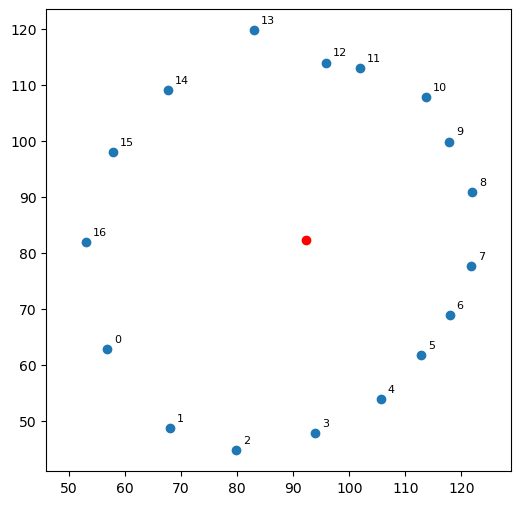

In [15]:
center_pos = frame0_pts.mean(axis=0)
plt.figure(figsize=(6, 6))  # Make plot larger for better label visibility

# Plot points and center
plt.scatter(frame0_pts[:, 0], frame0_pts[:, 1])
plt.scatter(center_pos[0], center_pos[1], color='red')

# Add index labels with slight offset
for i, (x, y) in enumerate(frame0_pts):
    plt.annotate(str(i), (x, y), 
                xytext=(5, 5),  # 5 points offset
                textcoords='offset points',
                fontsize=8)

plt.axis('equal')  # Keep aspect ratio equal
plt.show()

In [6]:
# test pol/cart conversion
trial_cnt = 500
for _ in range(trial_cnt):
    cart_pts = np.random.randint(-100, 100, size=(40, 2))
    center_pos = np.random.randint(-100, 100, size=2)
    cart_pts_reconverted = pol2cart(cart2pol(cart_pts, center_pos), center_pos)
    if not np.allclose(cart_pts, cart_pts_reconverted, atol=1e-2):
        print('cart2pol and pol2cart conversion failed')
        break
print('cart2pol and pol2cart conversion passed')

cart2pol and pol2cart conversion passed


In [29]:
frame0_pts

array([[ 56.8390274 ,  62.87812805],
       [ 67.929245  ,  48.65399551],
       [ 79.79259491,  44.7642746 ],
       [ 93.87147522,  47.882164  ],
       [105.60311127,  53.87807465],
       [112.83431244,  61.77319336],
       [117.91784668,  68.8447113 ],
       [121.6602478 ,  77.59156799],
       [121.91754913,  90.85507202],
       [117.80519104,  99.83609009],
       [113.6468277 , 107.78422546],
       [101.89625549, 112.92688751],
       [ 95.81559753, 113.93301392],
       [ 82.98293304, 119.68743896],
       [ 67.57627869, 108.99538422],
       [ 57.835495  ,  97.93512726],
       [ 52.94480133,  81.92545319]])

In [25]:
missing_idx = 13
frame0_pts_copy = frame0_pts.copy()
frame0_pts_copy[missing_idx] = (0, 0)
frame0_pts_interpolated = polar_interpolate(frame0_pts_copy)
print(f'true coords of pt {missing_idx}: {frame0_pts[missing_idx]}')
print(f'interpolated coords of pt {missing_idx}: {frame0_pts_interpolated[missing_idx]}')
frame0_pts_interpolated

prev_idx: 12, next_idx: 14
r1: 34.03232886282931, theta1: 85.03106384083637
r2: 38.45438643810924, theta2: 131.12496848009783
weight: 0.5
theta1: 85.03106384083637, theta2: 131.12496848009783
r_interp: 36.24335765046928, theta_interp: 108.07801616046712
n1: [ 95.81559753 113.93301392], n2: [ 67.57627869 108.99538422]
cart_interpolated_pts: [ 81.621128   114.48278461]
true coords of pt 13: [ 82.98293304 119.68743896]
interpolated coords of pt 13: [ 81.621128   114.48278461]


array([[ 56.8390274 ,  62.87812805],
       [ 67.929245  ,  48.65399551],
       [ 79.79259491,  44.7642746 ],
       [ 93.87147522,  47.882164  ],
       [105.60311127,  53.87807465],
       [112.83431244,  61.77319336],
       [117.91784668,  68.8447113 ],
       [121.6602478 ,  77.59156799],
       [121.91754913,  90.85507202],
       [117.80519104,  99.83609009],
       [113.6468277 , 107.78422546],
       [101.89625549, 112.92688751],
       [ 95.81559753, 113.93301392],
       [ 81.621128  , 114.48278461],
       [ 67.57627869, 108.99538422],
       [ 57.835495  ,  97.93512726],
       [ 52.94480133,  81.92545319]])

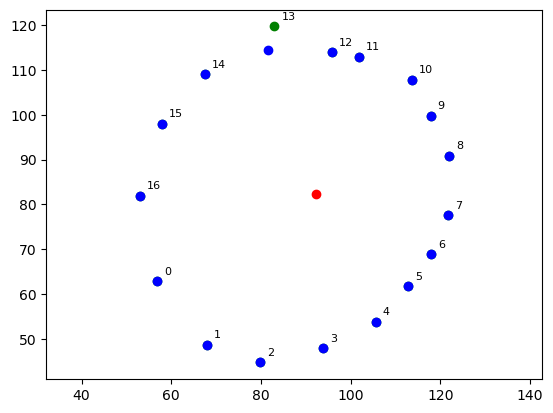

In [27]:
# plt.scatter(frame0_pts_interpolated[1:, 0], frame0_pts_interpolated[1:, 1])
center_pos = frame0_pts.mean(axis=0)
plt.scatter(frame0_pts[:, 0], frame0_pts[:, 1], color='green')
plt.scatter(frame0_pts_interpolated[:, 0], frame0_pts_interpolated[:, 1], color='blue')
plt.scatter(center_pos[0], center_pos[1], color='red')
# # Add index labels with slight offset
for i, (x, y) in enumerate(frame0_pts):
    plt.annotate(str(i), (x, y), 
                xytext=(5, 5),  # 5 points offset
                textcoords='offset points',
                fontsize=8)
plt.axis('equal') 
plt.show()

In [149]:
gt_missing_cnt = get_missing_count(gt_pts)
gt_missing_cnt.sum()
gt_pts[0]

array([[ 56.60295868,  60.87563324],
       [ 68.68206787,  46.73610687],
       [ 80.61574554,  43.68745422],
       [ 94.9708252 ,  47.61587143],
       [106.76696777,  53.7705307 ],
       [114.70111847,  60.88126755],
       [119.81578064,  67.85535431],
       [123.68135071,  76.63490295],
       [124.88923645,  89.89317322],
       [120.56957245,  99.8326416 ],
       [115.78184509, 108.68973541],
       [103.76600647, 114.82064056],
       [ 95.96231842, 115.84321594],
       [ 82.82823181, 116.82115173],
       [ 64.97318268, 111.6648941 ],
       [ 54.65006256,  98.89769745],
       [ 50.69525528,  81.75627136]])

In [33]:
polar_interpolated_err = eval_interpolation(polar_interpolate, gt_pts[:3], verbose=True)

frame_idx: 0
curr_pt: [56.6  60.88], curr_pt_interpolated: [55.36 62.11], err: 1.76
curr_pt: [68.68 46.74], curr_pt_interpolated: [67.14 49.96], err: 3.57
curr_pt: [80.62 43.69], curr_pt_interpolated: [82.57 44.8 ], err: 2.25
curr_pt: [94.97 47.62], curr_pt_interpolated: [95.52 46.26], err: 1.46
curr_pt: [106.77  53.77], curr_pt_interpolated: [106.43  52.57], err: 1.25
curr_pt: [114.7   60.88], curr_pt_interpolated: [114.47  59.84], err: 1.07
curr_pt: [119.82  67.86], curr_pt_interpolated: [120.35  68.03], err: 0.56
curr_pt: [123.68  76.63], curr_pt_interpolated: [124.35  78.19], err: 1.69
curr_pt: [124.89  89.89], curr_pt_interpolated: [124.35  88.38], err: 1.61
curr_pt: [120.57  99.83], curr_pt_interpolated: [121.9   99.86], err: 1.33
curr_pt: [115.78 108.69], curr_pt_interpolated: [113.57 108.69], err: 2.22
curr_pt: [103.77 114.82], curr_pt_interpolated: [106.35 113.85], err: 2.76
curr_pt: [ 95.96 115.84], curr_pt_interpolated: [ 93.58 117.41], err: 2.85
curr_pt: [ 82.83 116.82], cu

In [34]:
polar_interpolated_err = eval_interpolation(polar_interpolate, gt_pts)

In [35]:
polar_interpolated_err.mean()

4.071502833542421

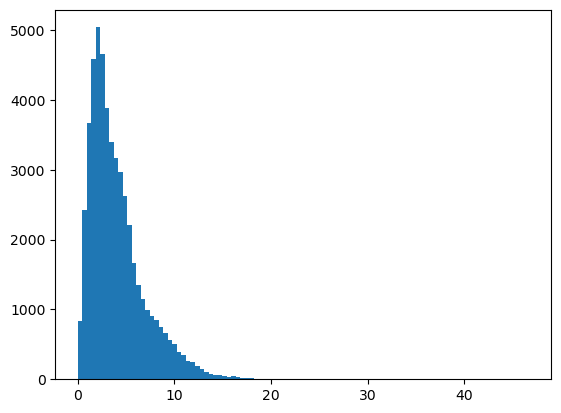

In [36]:
polar_interpolated_err_flat = polar_interpolated_err.flatten()
plt.hist(polar_interpolated_err_flat, bins=100)
plt.show()